In [17]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path
import orca

from mazsim import data_loader, variable_loader

In [18]:
project_dir = Path.cwd().parent
orca.add_injectable("project_dir", project_dir)
orca.run(['load_settings', 'load_data', 'build_networks','register_variables'])

Running step 'load_settings'
Registered injectable: data_dir: data
Registered injectable: output_dir: output
Registered injectable: data_model: data_model.py
Registered injectable: geography_id: block_id
Registered injectable: base_year: 2020
Registered injectable: end_year: 2050
Registered injectable: calibrated: True
Registered injectable: hh_ct_type: subregional
Registered injectable: job_ct_type: subregional
Registered injectable: housing_vacancy_rate: 0.05
Registered injectable: output_tables: ['households', 'persons', 'jobs', 'housing_units']
Registered injectable: custom_steps_dir: configs
Registered injectable: custom_steps_files: ['custom_steps.py']
Registered injectable: custom_variables_dir: configs
Registered injectable: custom_variables_files: ['custom_variables.py']
Registered injectable: submodel_groups: {'hlcm': {'ct_type': 'hh_ct_type'}, 'hulcm': {'ct_type': 'hh_ct_type', 'unsegmented_injectable': 'reg_hulcm_step_names'}, 'jlcm': {'ct_type': 'job_ct_type', 'unsegmented

In [19]:
from urbansim.models import util
from urbansim_templates import modelmanager as mm
from urbansim_templates.models import LargeMultinomialLogitStep

from urbansim.models.util import (columns_in_filters, columns_in_formula)
from choicemodels.tools import MergedChoiceTable

mm.initialize(Path.joinpath(project_dir, "configs"))

No files from ModelManager 0.1.dev8 or later found in path 'c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs'


In [20]:
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import seaborn as sb

from bokeh.io import output_notebook#, show
# from bokeh.plotting import Figure
# from datashader.bokeh_ext import create_ramp_legend, create_categorical_legend

output_notebook()

import datashader.transfer_functions as tf

import datashader as ds
from datashader.colors import viridis

def visualize_variable(variable_name):
    p = orca.get_table('blocks').to_frame(['x', 'y', variable_name])
    
    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean(variable_name))
    img = tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def summed_probas(sum_variable, probas):
    p = orca.get_table('blocks').to_frame([sum_variable])
    p['proba'] = probas

    summed_puma = p.groupby(sum_variable).proba.sum()

    (summed_puma / summed_puma.sum()).plot(kind='bar')

def plot_probas(proba):
    p = orca.get_table('blocks').to_frame(['x', 'y'])
    p['proba'] = proba

    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean('proba'))
    img= tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def corr_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)

    X = orca.get_table('blocks').to_frame(cols)

    plt.subplots(figsize=(12, 12))
    sb.heatmap(X.corr(), annot=True, cmap="RdYlGn")
    plt.show()
    
def skew_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)
            
    X = orca.get_table('blocks').to_frame(cols)
    X.skew().plot(kind='bar')

def create_probs_table(m, rep_chooser_filter = None, sample_alts= None, sample_choosers= None,idx='building_id'):
    filter_cols = columns_in_filters(to_str(m.chooser_filters) + " " + to_str(m.alt_filters) + to_str(rep_chooser_filter))
    colnames = columns_in_formula(m.model_expression) + columns_in_filters(filter_cols)
    alts = orca.get_table(m.alternatives).to_frame(colnames)
    alts = alts.query(to_str(m.alt_filters)) if m.alt_filters else alts
    obs = orca.get_table(m.choosers).to_frame(colnames)
    obs = obs.query(to_str(m.chooser_filters)) if m.chooser_filters else obs
    if idx in obs.columns:
        obs = obs.drop(columns=[idx])
    # Filter representative chooser based on rep_chooser_filter input
    if rep_chooser_filter:
        # check if rep_filter has columns from the interaction terms
        if (all(x in obs.columns for x in columns_in_filters(to_str(rep_chooser_filter)))):
            obs = obs.query(to_str(rep_chooser_filter))
        else:
            chooser_vars = [x for x in columns_in_formula(m.model_expression) if x in orca.get_table(m.choosers).columns]
            raise ValueError("Representative choosers' filters must be on these columns:\n *{}".format('\n *'.join(chooser_vars)))
    if sample_choosers:
        if sample_choosers <= len(obs):
            obs = obs.sample(n= sample_choosers)
        else:
            obs
    if len(obs) == 0:
        raise ValueError('No choosers left after filtering.')
    if len(alts) == 0:
        raise ValueError('No alternatives left after filtering.')
    
    if not sample_alts:
        sample_alts = len(alts)
    mtc = MergedChoiceTable(obs, alts, sample_size= sample_alts)
    probas = m.model.probabilities(mtc)
    probas = probas.reset_index(level=1).groupby(idx).sum()
    return probas

def to_str(w):
    if isinstance(w, str):
        return w
    if isinstance(w, list):
        return ' & '.join(w) if len(w) > 1 else w[0]
    if not w:
        return " "

Loading BokehJS ...

Calculating proportion children 0 for blocks
Calculating number of households for blocks


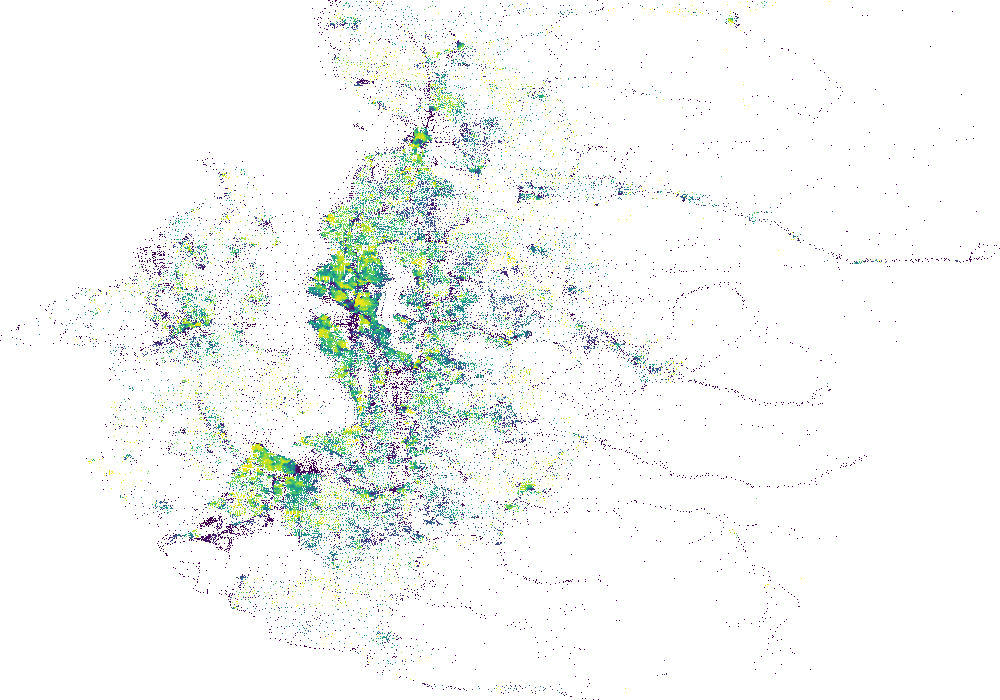

In [21]:
visualize_variable('st_prop_children_0_ave_400_flat')

In [22]:
# Set explanatory variables
expl_vars = [
    'major_road_node_sum_800_flat',
    'st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time',
    'st_prop_aggr_sector_id_1_ave_1600_flat', 
    'st_prop_aggr_sector_id_2_ave_1600_flat', 
    'st_prop_aggr_sector_id_3_ave_1600_flat',
    'st_prop_aggr_sector_id_4_ave_1600_flat',
    'st_prop_aggr_sector_id_5_ave_1600_flat',
    'st_ln_block_groups_mean_res_value', 
    'st_ln_block_groups_mean_res_rent',
    'st_total_households_sum_2000_linear',                    
    'st_block_groups_median_year_built',
    'st_is_transit_stop_sum_1600_flat',
    'st_block_groups_median_income', 
    'st_block_groups_prop_built_after_2010_1', 
    'st_prop_children_0_ave_400_flat',
    'st_sum_income_ave_1600_flat'
]

In [23]:
# hulcm1: Single-family owner housing units
m = LargeMultinomialLogitStep()
m.choosers = ['housing_units']
m.chooser_sample_size = 5000
m.chooser_filters = '(year_built > 2010) & (unit_type_id == 1)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 50 
m.out_chooser_filters = '(block_id == "-1") & (year_built > 2010) & (unit_type_id == 1)'
m.alt_capacity = 'vacant_du_spaces_clip'
m.out_alt_filters = 'vacant_du_spaces_clip > 0'
m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hulcm1'

Calculating proportion aggr_sector_id 4 for blocks
Calculating number of jobs for blocks
Disaggregating median_income to blocks from block_groups
Calculating median_income of households for block_groups
Disaggregating block_group_id to households from blocks
Disaggregating prop_built_after_2010_1 to blocks from block_groups
Disaggregating block_group_id to housing_units from blocks
Calculating proportion built_after_2010 1 for block_groups
Calculating number of housing_units for block_groups
Calculating proportion aggr_sector_id 1 for blocks
Calculating proportion aggr_sector_id 3 for blocks
Calculating sum_income of households for blocks
Disaggregating mean_res_rent to blocks from block_groups
Calculating mean_res_rent of blocks for block_groups
Disaggregating mean_res_value to blocks from block_groups
Calculating mean_res_value of blocks for block_groups
Calculating proportion aggr_sector_id 5 for blocks
Disaggregating total_jobs_15_minutes_am_single_vehicle_to_work_travel_time to bl

In [24]:
# register model (will overwrite previous model)
mm.register(m)

Saving 'hulcm1.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs
Registering model step 'hulcm1'


In [25]:
# hulcm2: Single-family renter housing units
m = LargeMultinomialLogitStep()
m.choosers = ['housing_units']
# m.chooser_sample_size = 1000
m.chooser_filters = '(year_built > 2010) & (unit_type_id == 2)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 50 
m.out_chooser_filters = '(block_id == "-1") & (year_built > 2010) & (unit_type_id == 2)'
m.alt_capacity = 'vacant_du_spaces_clip'
m.out_alt_filters = 'vacant_du_spaces_clip > 0'
m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hulcm2'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:            554
Model:         Multinomial Logit   Df Residuals:                538
Method:       Maximum Likelihood   Df Model:                     16
Date:                 2026-09-16   Pseudo R-squ.:             0.337
Time:                      12:55   Pseudo R-bar-squ.:         0.330
AIC:                   2,903.985   Log-Likelihood:       -1,435.992
BIC:                   2,973.059   LL-Null:              -2,167.261
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
major_road_node_sum_800_flat                                               0.1434     0.056     2.546     0.011             
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time   -0.4585

In [26]:
# register model (will overwrite previous model)
mm.register(m)

Saving 'hulcm2.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs
Registering model step 'hulcm2'


In [27]:
# hulcm3: Multi-family owner housing units
m = LargeMultinomialLogitStep()
m.choosers = ['housing_units']
# m.chooser_sample_size = 5000
m.chooser_filters = '(year_built > 2010) & (unit_type_id == 3)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 50 
m.out_chooser_filters = '(block_id == "-1") & (year_built > 2010) & (unit_type_id == 3)'
m.alt_capacity = 'vacant_du_spaces_clip'
m.out_alt_filters = 'vacant_du_spaces_clip > 0'
m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hulcm3'

        0.02193874,  0.03434035, -0.17422101,  0.21915586, -0.41108332,
        0.24802331, -0.2172686 , -0.55770081,  0.38122102,  0.47851404,
        1.8115964 ]), 7717.705495161282, {'grad': array([-4.46827895e-05, -1.06089252e-05, -9.33929820e-06, -3.13917731e-07,
       -9.72131315e-05, -4.73075229e-06, -4.09555666e-05, -1.14825732e-05,
        4.75485992e-06, -4.91310861e-05, -1.83420912e-07, -2.79849634e-05,
        2.86086062e-05,  5.23052292e-06, -4.07376254e-05, -1.71908904e-05]), 'task': 'ABNORMAL: ', 'funcalls': 89, 'nit': 39, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,287
Model:         Multinomial Logit   Df Residuals:              2,271
Method:       Maximum Likelihood   Df Model:                     16
Date:                 2026-09-16   Pseudo R-squ.:             0.137
Time:                      12:55   Pseudo R-bar-squ.:         0.136
AIC:                  15,467.411   Log-Likelihood:       -7,717.705
BIC:                  15,559.171   LL-Null:              -8,946.797
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
major_road_node_sum_800_flat                                              -0.2647     0.032    -8.298     0.000             
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time   -0.1500

In [28]:
# register model (will overwrite previous model)
mm.register(m)

Saving 'hulcm3.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs
Registering model step 'hulcm3'


In [29]:
# hulcm4: Multi-family renter housing units
m = LargeMultinomialLogitStep()
m.choosers = ['housing_units']
m.chooser_sample_size = 5000
m.chooser_filters = '(year_built > 2010) & (unit_type_id == 4)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 50 
m.out_chooser_filters = '(block_id == "-1") & (year_built > 2010) & (unit_type_id == 4)'
m.alt_capacity = 'vacant_du_spaces_clip'
m.out_alt_filters = 'vacant_du_spaces_clip > 0'
m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hulcm4'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          5,000
Model:         Multinomial Logit   Df Residuals:              4,984
Method:       Maximum Likelihood   Df Model:                     16
Date:                 2026-09-16   Pseudo R-squ.:             0.256
Time:                      12:55   Pseudo R-bar-squ.:         0.256
AIC:                  29,123.608   Log-Likelihood:      -14,545.804
BIC:                  29,227.883   LL-Null:             -19,560.115
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
major_road_node_sum_800_flat                                               0.0632     0.017     3.711     0.000             
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time    0.3647

In [30]:
# register model (will overwrite previous model)
mm.register(m)

Saving 'hulcm4.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs
Registering model step 'hulcm4'
